### 단백질 구조에 따른 활성화 예측 모델

In [1]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import Crippen
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import AllChem
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

C:\Users\USER\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
# 데이터 import
df = pd.read_csv('cmpd.csv')
df

,inchikey,smiles,group,activity
0,FNHKPVJBJVTLMP-UHFFFAOYSA-N,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,train,active
1,CUDVHEFYRIWYQD-UHFFFAOYSA-N,CNC(=O)c1cccc2cc(Oc3ccnc4cc(OCC5(N)CC5)c(OC)cc...,train,active
2,TTZSNFLLYPYKIL-UHFFFAOYSA-N,Cc1cc2cc(Oc3ccnc(Nc4cccc(CS(=O)(=O)NCCN(C)C)c4...,test,active
3,UOVCGJXDGOGOCZ-UHFFFAOYSA-N,COc1cc2c(cc1F)C(c1ccccc1Cl)=Nc1c(n[nH]c1C)N2,train,active
4,CUIHSIWYWATEQL-UHFFFAOYSA-N,Cc1ccc(Nc2nccc(N(C)c3ccc4c(C)n(C)nc4c3)n2)cc1S...,test,active
...,...,...,...,...
5525,UBAHPEHGSJRHGA-UHFFFAOYSA-N,Cc1cccc2nc(-c3ccc(-c4cccc(CN5CCC(C(N)=O)CC5)c4...,test,inactive
5526,RTTIKBHDHKOSNI-UHFFFAOYSA-N,Cc1c2ccccc2nc2c1c1cc(NCCN(C)C)ccc1n2CCN(C)C,test,inactive
5527,HVUOSZANYULBJR-UHFFFAOYSA-N,Cc1ccc(-c2ccn(-c3ccc4c5c(n(C)c4c3)CCCNC5)c(=O)...,test,inactive
5528,SNFWCJIVWUVRNO-UHFFFAOYSA-N,N#Cc1c(-c2ccccc2C(F)(F)F)nc(SCc2ccc(OC(F)(F)F)...,test,inactive


In [4]:
# 데이터 info 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5530 entries, 0 to 5529
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   inchikey  5530 non-null   object
 1   smiles    5530 non-null   object
 2   group     5530 non-null   object
 3   activity  5530 non-null   object
dtypes: object(4)
memory usage: 172.9+ KB


In [5]:
# 결측치 확인
df.isnull().sum()

inchikey    0
smiles      0
group       0
activity    0
dtype: int64

#### 추가 생성할 수 있는 화학 특성

- MolecularWeight : 원자들의 질량의 합
- LogP : 지용성/친수성 비율
- Topological Polar Surface Area(TPSA) : 분자의 극성표면력
- Molecular Fingerprints : 벡터화된 분자의 구조 정보
- Hydrogen Bond Donors (HBD): 수소 결합 공여자 수
- Hydrogen Bond Acceptors (HBA): 수소 결합 수용자 수
- Rotatable Bonds: 회전 가능한 결합의 수
- Aromatic Rings: 방향족 고리의 수
- Heavy Atom Count: 비수소 원자의 개수

In [6]:
import seaborn as sns

타겟데이터 값 :  {'inactive', 'unknown', 'intermediate', 'active'}


Text(0.5, 1.0, '[activity dist]')

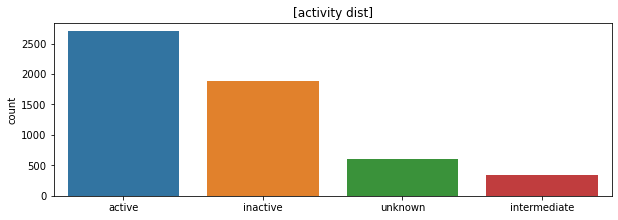

In [7]:
# 타겟데이터 분포 확인
print('타겟데이터 값 : ',set(df['activity']))

plt.figure(figsize=(10, 7))

plt.subplot(211)
sns.countplot(data=df, x="activity").set_xlabel('')
plt.title("[activity dist]")

In [8]:
# 전체 데이터 기준 활성화 여부별 개수
print(df['activity'].value_counts())

activity
active          2704
inactive        1886
unknown          599
intermediate     341
Name: count, dtype: int64


In [9]:
# 학습데이터와 테스트데이터 기준 활성화 여부별 개수 및 비율
pivot_count = pd.pivot_table(df, index = 'activity', columns='group', aggfunc='size')
pivot_ratio = pivot_count.div(pivot_count.sum(axis=0), axis=1)
display(pivot_count)
print('\n')
display(pivot_ratio)

group,test,train
activity,,
active,558,2146
inactive,811,1075
intermediate,71,270
unknown,113,486


group,test,train
activity,,
active,0.359305,0.539603
inactive,0.522215,0.270304
intermediate,0.045718,0.067890
unknown,0.072762,0.122203


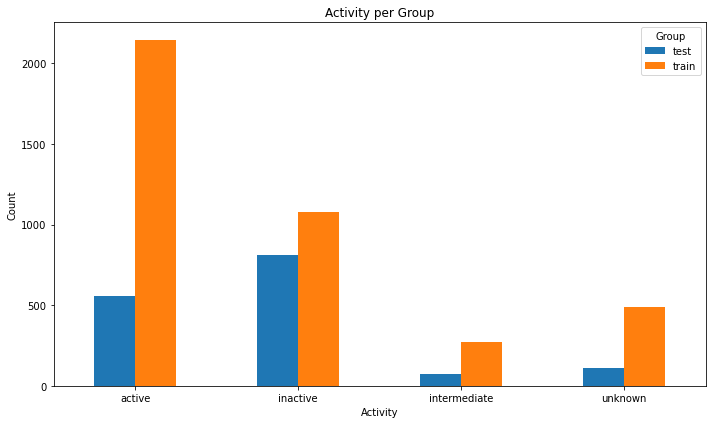

In [10]:
# 학습데이터와 테스트데이터 기준 활성화 여부 countplot
ax = pivot_count.plot(kind='bar', figsize=(10, 6))

ax.set_title('Activity per Group')
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.legend(title='Group')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Activity 값 분포에 대한 고찰
- active와 inactive는 학습 데이터에서는 active값의 비율이 크고, 테스트 데이터에서는 inactive값의 비율이 더 크게 나타남
- intermediate와 unknown은 차지하는 비율이 적으며, unkown은 제거해도 학습 가능할 것으로 보임
- intermediate은 차지하는 비율은 적지만 '중간 상태'라는 값이 의미가 있을 것으로 보여 학습대상이 되야할지 고민이 필요함(포함시킨다고 하면 클래스 불균형 해소방법에 대한 탐색이 필요함)
- 여기서는 active와 inactive 이진분류로만 수행할 예정

In [11]:
# smiles분자식의 최소/최대 길이 확인

min_length = df['smiles'].str.len().min()
max_length = df['smiles'].str.len().max()
print('최소 길이 : ', min_length)
print('최대 길이 : ', max_length)

최소 길이 :  14
최대 길이 :  282


In [12]:
# 추가할 화학 특성들 생성
df['MolecularWeight'] = df['smiles'].apply(lambda x: Chem.MolFromSmiles(x) if pd.notna(x) else None)
df['MolecularWeight'] = df['MolecularWeight'].apply(lambda x: Descriptors.MolWt(x) if pd.notna(x) else None)
df['LogP'] = df['smiles'].apply(lambda x: Crippen.MolLogP(Chem.MolFromSmiles(x)) if pd.notna(x) else None)
df['tpsa'] = df['smiles'].apply(lambda x: rdMolDescriptors.CalcTPSA(Chem.MolFromSmiles(x)) if pd.notna(x) else None)
df['hba'] = df['smiles'].apply(lambda x: Descriptors.NumHAcceptors(Chem.MolFromSmiles(x)) if pd.notna(x) else None)
df['hbd'] = df['smiles'].apply(lambda x: Descriptors.NumHDonors(Chem.MolFromSmiles(x)) if pd.notna(x) else None)

In [13]:
# fingerprint 생성 함수
def generate_fingerprints(df):
    fingerprints = []
    for smiles in df['smiles']:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None: 
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
            fingerprints.append(np.array(fp))
        else:
            print(f"Invalid SMILES: {smiles}")
            fingerprints.append(None)
    df['fingerprint'] = fingerprints
    return df

In [14]:
# fingerprint 컬럼 데이터 생성
df = generate_fingerprints(df)

[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerator
[20:59:32] DEPRECATION WARNING: please use MorganGenerat

In [15]:
# fingerprint 컬럼 데이터 생성
X_FP = df['fingerprint']

In [16]:
#원본데이터 저장
origin_df = df
origin_df

,inchikey,smiles,group,activity,MolecularWeight,LogP,tpsa,hba,hbd,fingerprint
0,FNHKPVJBJVTLMP-UHFFFAOYSA-N,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,train,active,482.821,5.68880,92.35,4,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
1,CUDVHEFYRIWYQD-UHFFFAOYSA-N,CNC(=O)c1cccc2cc(Oc3ccnc4cc(OCC5(N)CC5)c(OC)cc...,train,active,443.503,4.41860,95.70,6,2,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, ..."
2,TTZSNFLLYPYKIL-UHFFFAOYSA-N,Cc1cc2cc(Oc3ccnc(Nc4cccc(CS(=O)(=O)NCCN(C)C)c4...,test,active,480.594,3.78322,112.24,7,3,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,UOVCGJXDGOGOCZ-UHFFFAOYSA-N,COc1cc2c(cc1F)C(c1ccccc1Cl)=Nc1c(n[nH]c1C)N2,train,active,356.788,4.74532,62.30,4,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CUIHSIWYWATEQL-UHFFFAOYSA-N,Cc1ccc(Nc2nccc(N(C)c3ccc4c(C)n(C)nc4c3)n2)cc1S...,test,active,437.529,3.13904,119.03,8,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...
5525,UBAHPEHGSJRHGA-UHFFFAOYSA-N,Cc1cccc2nc(-c3ccc(-c4cccc(CN5CCC(C(N)=O)CC5)c4...,test,inactive,538.570,5.53592,112.31,4,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5526,RTTIKBHDHKOSNI-UHFFFAOYSA-N,Cc1c2ccccc2nc2c1c1cc(NCCN(C)C)ccc1n2CCN(C)C,test,inactive,389.547,4.18622,36.33,5,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5527,HVUOSZANYULBJR-UHFFFAOYSA-N,Cc1ccc(-c2ccn(-c3ccc4c5c(n(C)c4c3)CCCNC5)c(=O)...,test,inactive,384.483,3.73542,51.85,5,1,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
5528,SNFWCJIVWUVRNO-UHFFFAOYSA-N,N#Cc1c(-c2ccccc2C(F)(F)F)nc(SCc2ccc(OC(F)(F)F)...,test,inactive,471.382,5.51828,78.77,5,1,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [17]:
# 타겟값이 active와 inactive인 데이터만 추출
target_data = ['active', 'inactive']
df = df[df['activity'].isin(target_data)]
df.index = range(len(df))
df

,inchikey,smiles,group,activity,MolecularWeight,LogP,tpsa,hba,hbd,fingerprint
0,FNHKPVJBJVTLMP-UHFFFAOYSA-N,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,train,active,482.821,5.68880,92.35,4,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
1,CUDVHEFYRIWYQD-UHFFFAOYSA-N,CNC(=O)c1cccc2cc(Oc3ccnc4cc(OCC5(N)CC5)c(OC)cc...,train,active,443.503,4.41860,95.70,6,2,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, ..."
2,TTZSNFLLYPYKIL-UHFFFAOYSA-N,Cc1cc2cc(Oc3ccnc(Nc4cccc(CS(=O)(=O)NCCN(C)C)c4...,test,active,480.594,3.78322,112.24,7,3,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,UOVCGJXDGOGOCZ-UHFFFAOYSA-N,COc1cc2c(cc1F)C(c1ccccc1Cl)=Nc1c(n[nH]c1C)N2,train,active,356.788,4.74532,62.30,4,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CUIHSIWYWATEQL-UHFFFAOYSA-N,Cc1ccc(Nc2nccc(N(C)c3ccc4c(C)n(C)nc4c3)n2)cc1S...,test,active,437.529,3.13904,119.03,8,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...
4585,UBAHPEHGSJRHGA-UHFFFAOYSA-N,Cc1cccc2nc(-c3ccc(-c4cccc(CN5CCC(C(N)=O)CC5)c4...,test,inactive,538.570,5.53592,112.31,4,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4586,RTTIKBHDHKOSNI-UHFFFAOYSA-N,Cc1c2ccccc2nc2c1c1cc(NCCN(C)C)ccc1n2CCN(C)C,test,inactive,389.547,4.18622,36.33,5,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4587,HVUOSZANYULBJR-UHFFFAOYSA-N,Cc1ccc(-c2ccn(-c3ccc4c5c(n(C)c4c3)CCCNC5)c(=O)...,test,inactive,384.483,3.73542,51.85,5,1,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
4588,SNFWCJIVWUVRNO-UHFFFAOYSA-N,N#Cc1c(-c2ccccc2C(F)(F)F)nc(SCc2ccc(OC(F)(F)F)...,test,inactive,471.382,5.51828,78.77,5,1,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [18]:
# 타겟데이터 컬럼의 활성화 여부를 1과 0으로 변환
df['activity'] = df['activity'].replace({'active' : 1, 'inactive' : 0})
df

,inchikey,smiles,group,activity,MolecularWeight,LogP,tpsa,hba,hbd,fingerprint
0,FNHKPVJBJVTLMP-UHFFFAOYSA-N,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...,train,1,482.821,5.68880,92.35,4,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
1,CUDVHEFYRIWYQD-UHFFFAOYSA-N,CNC(=O)c1cccc2cc(Oc3ccnc4cc(OCC5(N)CC5)c(OC)cc...,train,1,443.503,4.41860,95.70,6,2,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, ..."
2,TTZSNFLLYPYKIL-UHFFFAOYSA-N,Cc1cc2cc(Oc3ccnc(Nc4cccc(CS(=O)(=O)NCCN(C)C)c4...,test,1,480.594,3.78322,112.24,7,3,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,UOVCGJXDGOGOCZ-UHFFFAOYSA-N,COc1cc2c(cc1F)C(c1ccccc1Cl)=Nc1c(n[nH]c1C)N2,train,1,356.788,4.74532,62.30,4,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CUIHSIWYWATEQL-UHFFFAOYSA-N,Cc1ccc(Nc2nccc(N(C)c3ccc4c(C)n(C)nc4c3)n2)cc1S...,test,1,437.529,3.13904,119.03,8,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...
4585,UBAHPEHGSJRHGA-UHFFFAOYSA-N,Cc1cccc2nc(-c3ccc(-c4cccc(CN5CCC(C(N)=O)CC5)c4...,test,0,538.570,5.53592,112.31,4,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4586,RTTIKBHDHKOSNI-UHFFFAOYSA-N,Cc1c2ccccc2nc2c1c1cc(NCCN(C)C)ccc1n2CCN(C)C,test,0,389.547,4.18622,36.33,5,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4587,HVUOSZANYULBJR-UHFFFAOYSA-N,Cc1ccc(-c2ccn(-c3ccc4c5c(n(C)c4c3)CCCNC5)c(=O)...,test,0,384.483,3.73542,51.85,5,1,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
4588,SNFWCJIVWUVRNO-UHFFFAOYSA-N,N#Cc1c(-c2ccccc2C(F)(F)F)nc(SCc2ccc(OC(F)(F)F)...,test,0,471.382,5.51828,78.77,5,1,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [19]:
# 학습/테스트 데이터 분리
train_df = df[df['group'] == 'train']
test_df = df[df['group'] == 'test']

train_df.index = range(len(train_df))
test_df.index = range(len(test_df))

print('학습데이터 수 : ', len(train_df))
print('테스트데이터 수 : ', len(test_df))
print(f'학습 데이터 비율 : {(len(train_df) / len(df)) * 100 : .2f}%')

학습데이터 수 :  3221
테스트데이터 수 :  1369
학습 데이터 비율 :  70.17%


In [20]:
# 필요한 변수들만 따로 설정
train_X_df = train_df[['MolecularWeight', 'LogP', 'tpsa', 'hba', 'hbd']]
test_X_df = test_df[['MolecularWeight', 'LogP', 'tpsa', 'hba', 'hbd']]
train_y = train_df['activity']
test_y = test_df['activity']

In [21]:
# fingerprint 데이터프레임화 수행(fingerprint만 독립변수로 쓰는 모델에 사용)
train_X_fp = pd.DataFrame(train_df['fingerprint'].tolist(), columns=[f'fp_{i}' for i in range(1024)])
test_X_fp = pd.DataFrame(test_df['fingerprint'].tolist(), columns=[f'fp_{i}' for i in range(1024)])

In [22]:
# fingerprint와 다른 화학속성들을 합친 데이터프레임 생성(fingerprint + 추가 화학속성을 독립변수로 쓸 모델에 사용)
train_X_all = pd.concat([train_X_df, train_X_fp], axis =1)
test_X_all = pd.concat([test_X_df, test_X_fp], axis =1)

In [23]:
# 만들어진 변수들 shape 확인
print(train_X_fp.shape, test_X_fp.shape, train_X_all.shape, test_X_all.shape, train_y.shape, test_y.shape)

(3221, 1024) (1369, 1024) (3221, 1029) (1369, 1029) (3221,) (1369,)


In [24]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import ParameterGrid, cross_val_score, GridSearchCV
from sklearn.metrics import make_scorer, f1_score, accuracy_score
from tqdm import tqdm

In [25]:
# 하이퍼파라미터들 설정
# 모델은 랜덤포레스트, XG부스트, 라이트GBM, cat부스트 4개 사용
# f1-score는 컴퓨팅자원 문제로 제외
param_grids = {

    "XGBoost": {
        "model": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss"),
        "params": {
            "n_estimators": [50, 250, 500],
            "learning_rate": [0.01, 0.1, 0.5],
            "max_depth": [3, 5, 7, 10]
        }
    },
    "LightGBM": {
        "model": LGBMClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 250, 500],
            "learning_rate": [0.01, 0.1, 0.5],
            "num_leaves": [30, 50, 70]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 250, 500],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5, 10]
        }
    },
    "CatBoost": {
        "model": CatBoostClassifier(random_state=42, verbose=0),
        "params": {
            "iterations": [50, 150, 350],
            "learning_rate": [0.01, 0.1, 0.5],
            "depth": [4, 6, 8]
        }
    }
}

scoring = {
    'accuracy': make_scorer(accuracy_score),
    #'f1': make_scorer(f1_score)
}

In [56]:
# fingerprint데이터만 활용한 모델의 최적파라미터 및 예측결과
gs_results_fp = []

for model_name, config in param_grids.items():
    print(f"\nGrid Search for {model_name}...")
    model = config["model"]
    param_grid = config["params"]

    if model_name == "CatBoost":
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring='accuracy',
            refit=True,
            cv=5,
            verbose=0,
            n_jobs=-1
        )
        grid_search.fit(train_X_fp, train_y)
    else:
        with tqdm(total=len(ParameterGrid(param_grid)), desc=f"{model_name} Progress") as pbar:
            for params in ParameterGrid(param_grid):
                model.set_params(**params)  # 파라미터 설정
                model.fit(train_X_fp, train_y)
                pbar.update(1)
        
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring='accuracy',
            refit=True,
            cv=5,
            verbose=0,
            n_jobs=-1
        )
        grid_search.fit(train_X_fp, train_y)

    y_pred = grid_search.best_estimator_.predict(test_X_fp)
    accuracy = accuracy_score(test_y, y_pred)
    f1 = f1_score(test_y, y_pred, average="weighted")

    gs_results_fp.append({
        "Model": model_name,
        "Best Params": grid_search.best_params_,
        "Best Accuracy (CV)": grid_search.best_score_,
        "Test Accuracy": accuracy,
    })


Grid Search for XGBoost...


XGBoost Progress: 100%|██████████| 36/36 [00:57<00:00,  1.60s/it]



Grid Search for LightGBM...


LightGBM Progress:   4%|▎         | 1/27 [00:00<00:04,  5.70it/s]

[LightGBM] [Info] Number of positive: 2146, number of negative: 1075
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006179 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1808
[LightGBM] [Info] Number of data points in the train set: 3221, number of used features: 904
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.666253 -> initscore=0.691285
[LightGBM] [Info] Start training from score 0.691285
[LightGBM] [Info] Number of positive: 2146, number of negative: 1075
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005599 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1808
[LightGBM] [Info] Number of data points in the train set: 3221, number of used features: 904
[LightGBM] [Info] [binar

...

LightGBM Progress: 100%|██████████| 27/27 [00:15<00:00,  1.77it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Info] Number of positive: 2146, number of negative: 1075
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005787 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1808
[LightGBM] [Info] Number of data points in the train set: 3221, number of used features: 904
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.666253 -> initscore=0.691285
[LightGBM] [Info] Start training from score 0.691285

Grid Search for RandomForest...


RandomForest Progress: 100%|██████████| 27/27 [00:49<00:00,  1.85s/it]



Grid Search for CatBoost...


In [57]:
# fingerprint데이터만 활용한 모델의 최적파라미터 및 예측결과
gs_results_all = []

for model_name, config in param_grids.items():
    print(f"\nGrid Search for {model_name}...")
    model = config["model"]
    param_grid = config["params"]

    if model_name == "CatBoost":
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring='accuracy',
            refit=True,
            cv=5,
            verbose=0,
            n_jobs=-1
        )
        grid_search.fit(train_X_all, train_y)
    else:
        with tqdm(total=len(ParameterGrid(param_grid)), desc=f"{model_name} Progress") as pbar:
            for params in ParameterGrid(param_grid):
                model.set_params(**params)  # 파라미터 설정
                model.fit(train_X_all, train_y)
                pbar.update(1)
        
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring='accuracy',
            refit=True,
            cv=5,
            verbose=0,
            n_jobs=-1
        )
        grid_search.fit(train_X_all, train_y)

    y_pred = grid_search.best_estimator_.predict(test_X_all)
    accuracy = accuracy_score(test_y, y_pred)
    f1 = f1_score(test_y, y_pred, average="weighted")

    gs_results_all.append({
        "Model": model_name,
        "Best Params": grid_search.best_params_,
        "Best Accuracy (CV)": grid_search.best_score_,
        "Test Accuracy": accuracy
    })


Grid Search for XGBoost...


XGBoost Progress: 100%|██████████| 36/36 [00:59<00:00,  1.65s/it]



Grid Search for LightGBM...


LightGBM Progress:   0%|          | 0/27 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2146, number of negative: 1075
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2595
[LightGBM] [Info] Number of data points in the train set: 3221, number of used features: 909
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.666253 -> initscore=0.691285
[LightGBM] [Info] Start training from score 0.691285


...

LightGBM Progress: 100%|██████████| 27/27 [00:18<00:00,  1.46it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Info] Number of positive: 2146, number of negative: 1075
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009630 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2595
[LightGBM] [Info] Number of data points in the train set: 3221, number of used features: 909
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.666253 -> initscore=0.691285
[LightGBM] [Info] Start training from score 0.691285
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

RandomForest Progress: 100%|██████████| 27/27 [00:50<00:00,  1.88s/it]



Grid Search for CatBoost...


In [68]:
# fingerprint만 예측에 사용된 그리드서치 결과
gs_results_df_fp = pd.DataFrame(gs_results_fp)

print("fingerprint 활용한 예측 결과")
display(gs_results_df_fp.iloc[:, :4])

fingerprint 활용한 예측 결과


,Model,Best Params,Best Accuracy (CV),Test Accuracy
0,XGBoost,"{'learning_rate': 0.5, 'max_depth': 5, 'n_esti...",0.789559,0.795471
1,LightGBM,"{'learning_rate': 0.5, 'n_estimators': 50, 'nu...",0.792040,0.810080
2,RandomForest,"{'max_depth': None, 'min_samples_split': 10, '...",0.791426,0.832725
3,CatBoost,"{'depth': 4, 'iterations': 150, 'learning_rate...",0.788005,0.794010


In [69]:
# fingerprint + 추가 화학특성 모두 예측에 사용된 그리드서치 결과
gs_results_df_all = pd.DataFrame(gs_results_all)

# 결과 출력
print("fingerprint + 추가 화학특성 사용한 결과")
display(gs_results_df_all.iloc[:, :4])

fingerprint + 추가 화학특성 사용한 결과


,Model,Best Params,Best Accuracy (CV),Test Accuracy
0,XGBoost,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",0.790801,0.803506
1,LightGBM,"{'learning_rate': 0.5, 'n_estimators': 250, 'n...",0.797012,0.823959
2,RandomForest,"{'max_depth': None, 'min_samples_split': 10, '...",0.792664,0.819576
3,CatBoost,"{'depth': 8, 'iterations': 150, 'learning_rate...",0.790792,0.810080


### 그리드서치 및 모델 예측 결과
   
#### 1. fingerprint만 학습에 사용된 경우
- 학습 결과 정확도 약 79%대로 모두 비슷하였으나, 랜덤포레스트 모델이 테스트에서 높은 성능을 기록함
- 랜덤포레스트 약 83%, Lightgbm이 약 81%의 정확도를 보임
    
#### 2. fingerprint + 추가 화학특성이 학습에 사용된 경우
- 학습 결과 정확도는 fingerprint만 학습에 쓴 경우에 비해 모든 모델에서 성능이 조금 상승
- Lightgbm이 약 82%의 정확도를 보였으며, 랜덤포레스트 성능이 그 뒤를 따름

In [60]:
#gs_total_result = pd.concat([gs_results_df_fp, gs_results_df_all], axis = 0)
#gs_total_result.to_csv("prt_pred_gs_result.csv", index=False)

In [43]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [44]:
# 랜덤서치를 위한 파라미터 범위 지정
param_distributions = {
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": randint(100, 500),  # n_estimators 범위
            "max_depth": [None, 10, 20, 30],  # max_depth 값
            "min_samples_split": randint(2, 20)  # min_samples_split 범위
        }
    },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        "params": {
            "n_estimators": randint(100, 500),  # n_estimators 범위
            "learning_rate": uniform(0.01, 0.1),  # learning_rate 범위
            "max_depth": randint(3, 10),  # max_depth 값
            "subsample": uniform(0.5, 0.5)  # subsample 범위
        }
    },
    "LightGBM": {
        "model": LGBMClassifier(random_state=42),
        "params": {
            "n_estimators": randint(100, 500),
            "learning_rate": uniform(0.01, 0.1),
            "num_leaves": randint(20, 100)
        }
    },
    "CatBoost": {
        "model": CatBoostClassifier(verbose=0),
        "params": {
            "iterations": randint(100, 500),
            "depth": randint(3, 10),
            "learning_rate": uniform(0.01, 0.1)
        }
    }
}

In [52]:
# fingerprint만 활용하여 랜덤서치 수행
rd_best_models_fp = []

for model_name, config in param_distributions.items():
    print(f"\nRandomized Search for {model_name}...")
    model = config["model"]
    param_dist = config["params"]
    
    randomized_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=10,
        scoring="accuracy",
        cv=5,
        n_jobs=-1,
        verbose=0,
        random_state=42
    )
    
    randomized_search.fit(train_X_fp, train_y)
    
    best_params = randomized_search.best_params_
    best_score = randomized_search.best_score_

    predictions = randomized_search.predict(test_X_fp)
    accuracy = accuracy_score(test_y, predictions)
    
    rd_best_models_fp.append({
        "Model": model_name,
        "Best Params": best_params,
        "Best Accuracy (CV)": best_score,
        "Test Accuracy": accuracy
    })


Randomized Search for RandomForest...

Randomized Search for XGBoost...

Randomized Search for LightGBM...
[LightGBM] [Info] Number of positive: 2146, number of negative: 1075
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005447 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1808
[LightGBM] [Info] Number of data points in the train set: 3221, number of used features: 904
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.666253 -> initscore=0.691285
[LightGBM] [Info] Start training from score 0.691285

Randomized Search for CatBoost...


In [54]:
# fingerprint + 추가 화학특성 활용하여 랜덤서치 수행
rd_best_models_all = []

for model_name, config in param_distributions.items():
    print(f"\nRandomized Search for {model_name}...")
    model = config["model"]
    param_dist = config["params"]
    
    randomized_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=10,  # 10번의 무작위 샘플링
        scoring="accuracy",  # 정확도를 평가 지표로 사용
        cv=5,  # 5-fold 교차검증
        n_jobs=-1,  # 모든 CPU 코어를 사용
        verbose=0,
        random_state=42
    )
    
    randomized_search.fit(train_X_all, train_y)
    
    best_params = randomized_search.best_params_
    best_score = randomized_search.best_score_

    predictions = randomized_search.predict(test_X_all)
    accuracy = accuracy_score(test_y, predictions)
    
    rd_best_models_all.append({
        "Model": model_name,
        "Best Params": best_params,
        "Best Accuracy (CV)": best_score,
        "Test Accuracy": accuracy
    })


Randomized Search for RandomForest...

Randomized Search for XGBoost...

Randomized Search for LightGBM...
[LightGBM] [Info] Number of positive: 2146, number of negative: 1075
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010853 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2595
[LightGBM] [Info] Number of data points in the train set: 3221, number of used features: 909
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.666253 -> initscore=0.691285
[LightGBM] [Info] Start training from score 0.691285

Randomized Search for CatBoost...


In [55]:
# fingerprint + 추가 화학특성 모두 예측에 사용된 랜덤서치 결과
rd_results_df_all = pd.DataFrame(rd_best_models_all)
print('fingerprint 활용 결과 : ', rd_results_df_all)

fingerprint 활용 결과 :            Model                                        Best Params  \
0  RandomForest  {'max_depth': None, 'min_samples_split': 5, 'n...   
1       XGBoost  {'learning_rate': 0.06986584841970366, 'max_de...   
2      LightGBM  {'learning_rate': 0.047454011884736254, 'n_est...   
3      CatBoost  {'depth': 9, 'iterations': 448, 'learning_rate...   

   Best Accuracy (CV)  Test Accuracy  f1-score  
0            0.792664       0.824690  0.811688  
1            0.785836       0.829072  0.811688  
2            0.790799       0.799854  0.811688  
3            0.789246       0.815924  0.811688  


In [70]:
display('fingerprint 활용 결과 : ', rd_results_df_fp.iloc[:, :4])

'fingerprint 활용 결과 : '

,Model,Best Params,Best Accuracy (CV),Test Accuracy
0,RandomForest,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.788942,0.849525
1,XGBoost,"{'learning_rate': 0.06986584841970366, 'max_de...",0.788941,0.828342
2,LightGBM,"{'learning_rate': 0.07508884729488528, 'n_esti...",0.786765,0.800584
3,CatBoost,"{'depth': 9, 'iterations': 448, 'learning_rate...",0.779939,0.840760


In [71]:
display('fingerprint + 추가 화학속성 활용 결과 : ', rd_results_df_all.iloc[:, :4])

'fingerprint + 추가 화학속성 활용 결과 : '

,Model,Best Params,Best Accuracy (CV),Test Accuracy
0,RandomForest,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.792664,0.824690
1,XGBoost,"{'learning_rate': 0.06986584841970366, 'max_de...",0.785836,0.829072
2,LightGBM,"{'learning_rate': 0.047454011884736254, 'n_est...",0.790799,0.799854
3,CatBoost,"{'depth': 9, 'iterations': 448, 'learning_rate...",0.789246,0.815924


In [61]:
#rd_total_result = pd.concat([rd_results_df_fp, rd_results_df_all], axis = 0)
#rd_total_result.to_csv("prt_pred_rd_result.csv", index=False)

### 랜덤서치 및 모델 예측 결과
   
#### 1. fingerprint만 학습에 사용된 경우
- 테스트 정확도는 랜덤포레스트가 약 85%로 가장 높고 cat부스트가 84%로 나타남
    
#### 2. fingerprint + 추가 화학특성이 학습에 사용된 경우
- 학습 최고 성능이 XGBoost를 제외하고는 조금씩 상승했지만 나머지 모델들은 fingerprint만 학습에 사용한 모델에 비해 테스트 정확도 낮게 나타남
- XGBoost가 약 83%로 가장 높고, RandomForest가 그 뒤를 따름

### 결론
1. fingerprint만 학습시키고 랜덤서치로 하이퍼파라미터를 얻은 RandomForest 모델이 테스트에서 약 85%의 정확도를 보여 성능이 가장 좋았음
2. fingerprint와 추가 화학속성을 학습에 쓴 경우는 fingerprint만 학습에 쓴 경우에 비해 (랜덤서치 기준) XG부스트를 제외한 나머지 모델에서 조금의 정확도 상승을 보였으나, 테스트 정확도는 오히려 감소치를 보임
3. fingerprint와 추가 화학속성을 학습에 쓴 모델로는 XG부스트가 약 83%의 정확도를 보였으나 랜덤포레스트와 크게 차이 나지는 않았음